* [x] move lattice code to class
* [ ] add determination of specializer/generalizer; check implementation of specializer
* [ ] use KNN graph or graph from umap

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload 

In [7]:
import os

USER_PATH = '~/OneDrive - PNNL'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)

os.listdir(path)

['scenarios_wrevenues.csv',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

In [9]:
df_design = pd.read_csv(os.path.join(path, 'design_solutions.csv'), index_col=0)
df_design

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
Base_cotwdpge,2600.000000,36.200000,261.818246,32.184081,1040.759934,29.040111,2.529768,0.738513
Base_johnday,2600.000000,47.000000,358.915986,41.785961,1303.210991,45.328622,3.192498,0.959951
Base_mossland,2600.000000,36.000000,533.607121,32.006268,919.337641,28.506600,2.244915,0.733595
Base_tesla,5200.000000,52.800000,974.931412,46.942526,1422.478138,49.483370,3.473485,1.084099
Base_wcascade,2600.000000,30.000000,440.190421,26.671890,876.802486,25.572794,2.081571,0.605057
No ESS_cotwdpge,1991.001203,0.000000,200.492478,0.000000,1068.932503,19.655535,1.278009,0.000000
No ESS_johnday,2585.000202,0.000000,356.845345,0.000000,1338.568265,32.860630,1.618871,0.000000
No ESS_mossland,1980.000054,0.000000,406.362357,0.000000,944.294322,19.417396,1.144392,0.000000
No ESS_tesla,2904.000009,0.000000,544.461698,0.000000,1459.967335,36.666428,1.762601,0.000000
No ESS_wcascade,1650.001811,0.000000,279.351920,0.000000,899.138883,19.083300,1.050217,0.000000


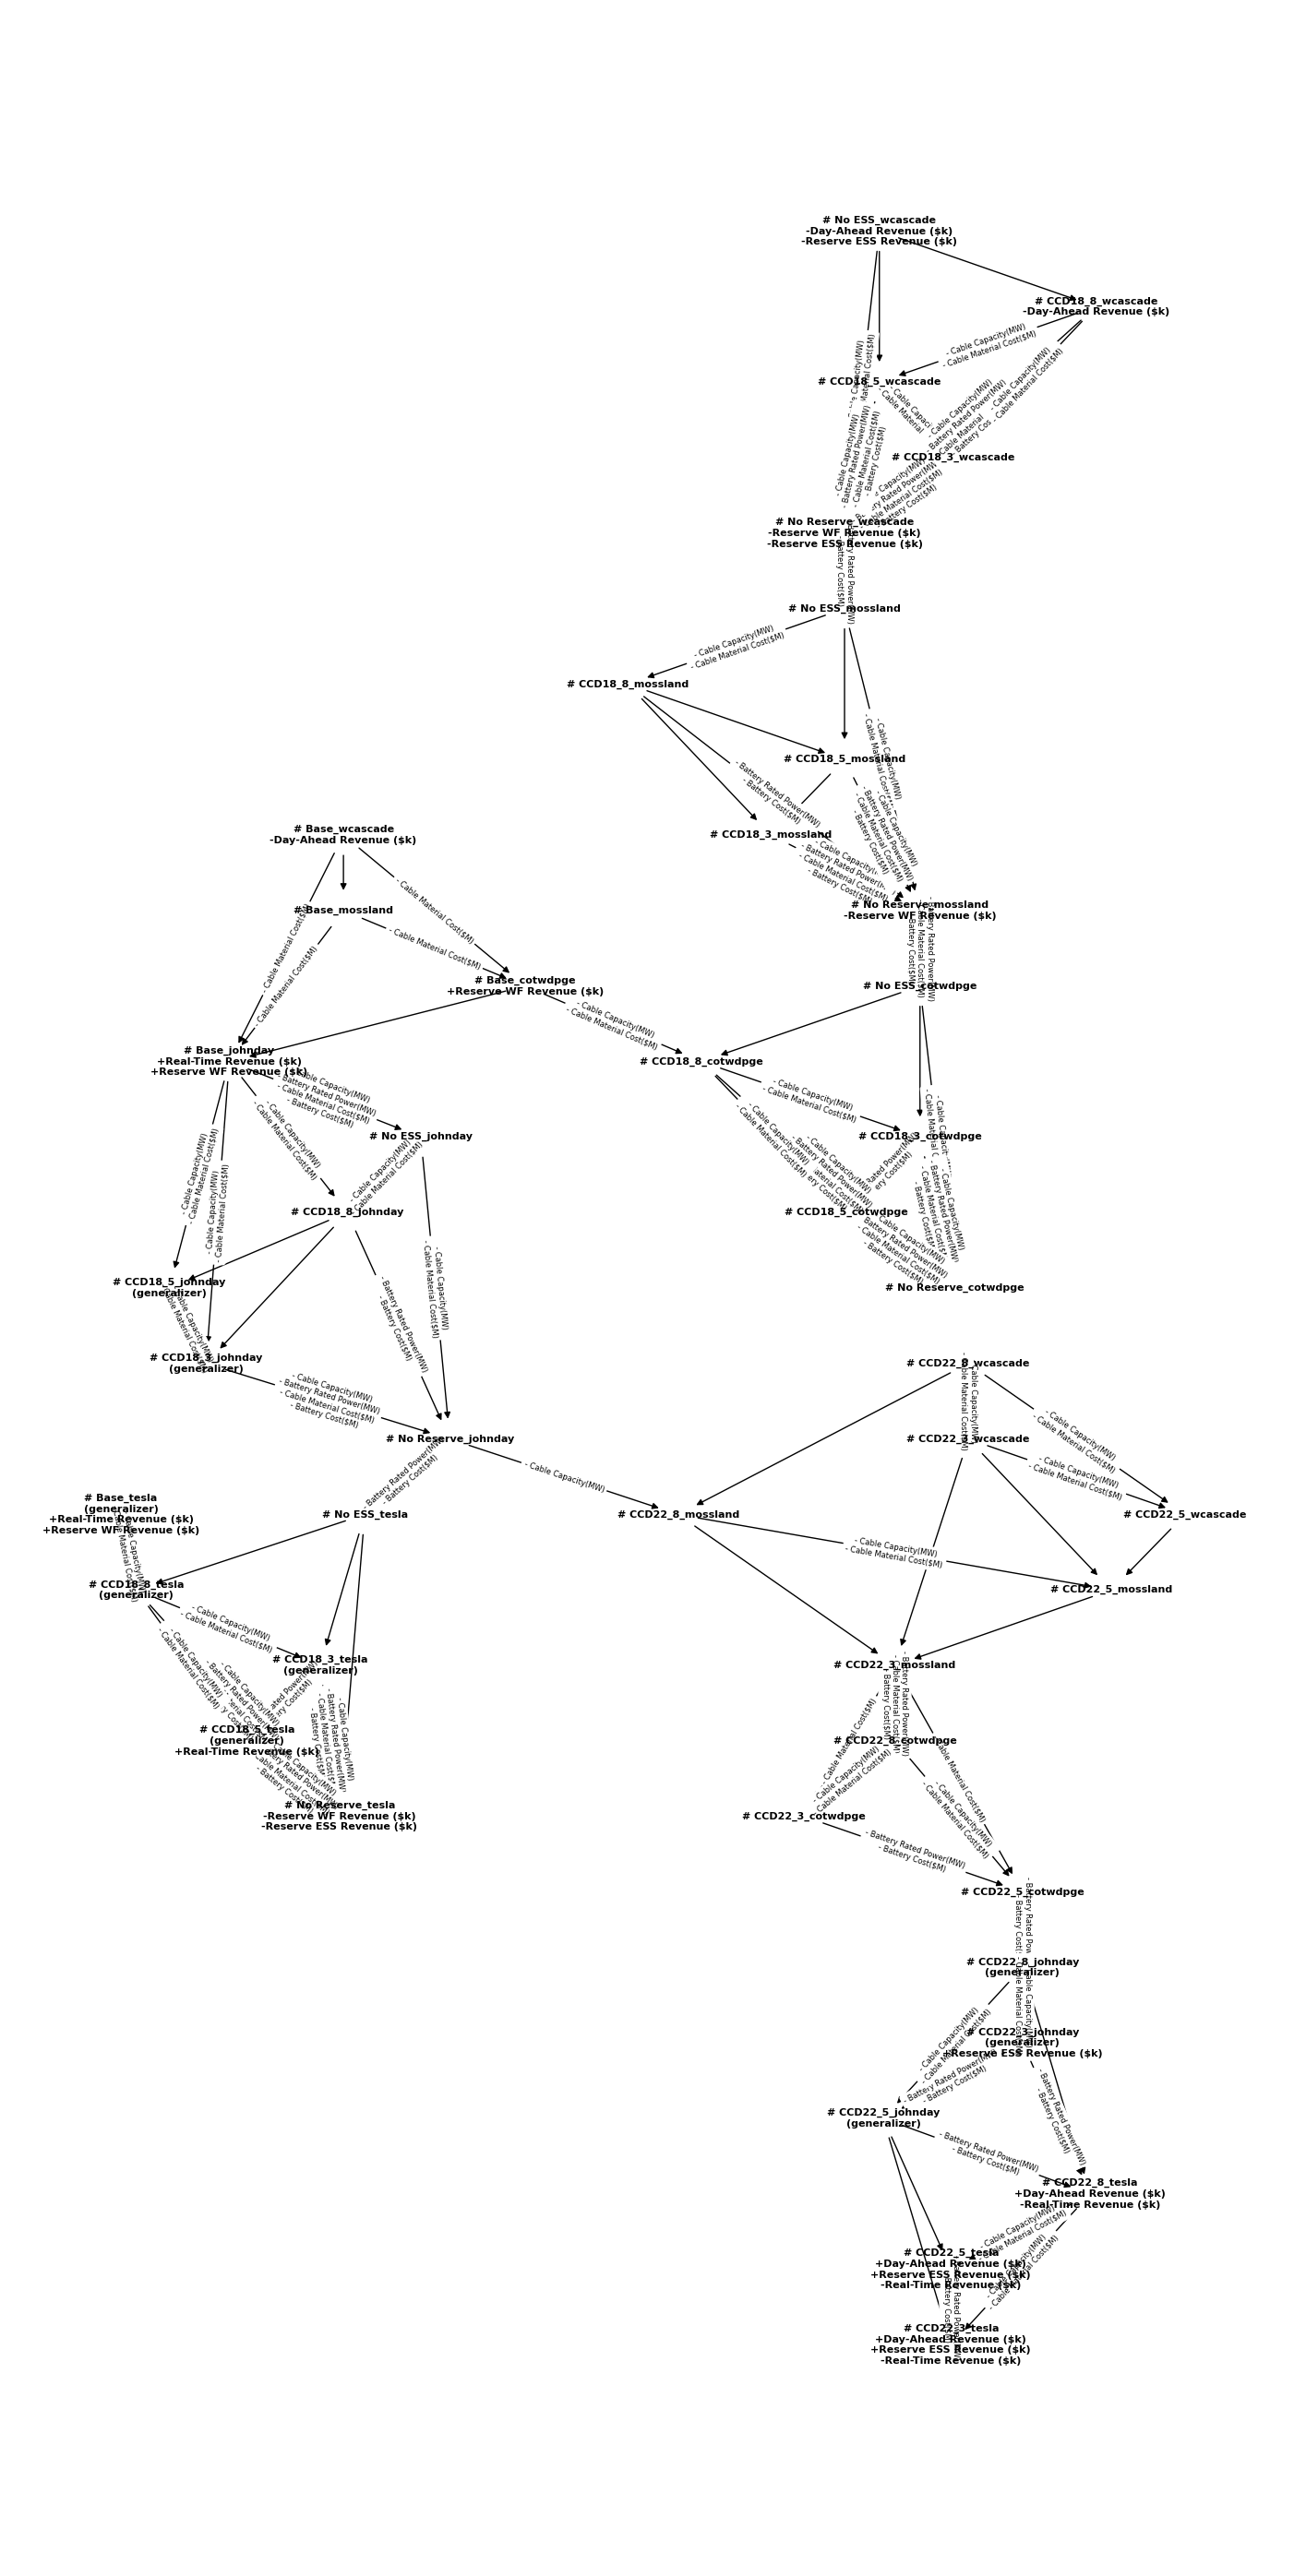

In [24]:
import tradeoff_lattice as tl; reload(tl)
            
ovars = [
    s
    for s in df_design.columns
    if 'Revenue' in s
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design, ovars, dvars,
    ascending=False,
    n_generalizers=9,
    n_specializers=3
)

plt.figure(figsize=(18, 36))
plt.axis('off')

self.draw(
    by=ovars[0],
    with_edge_labels=self.dvars,
    edge_labels_kwargs=dict(font_size=6),
    node_labels_kwargs=dict(fontsize=8, fontweight='bold')
)


In [ ]:
df_control = pd.read_csv(os.path.join(path, 'control_data.csv'))\
    .set_index(['config', 'sim', 'time'])
df_control

In [ ]:
def calc_closest_factors(c):
    a, b, i = 1, c, 0
    while a < b:
        i += 1
        if c % i == 0:
            a = i
            b = c//a

    return max(b, a), min(b, a)

def best_dims(n, armax=1.5):
    def objective(x):
        a, b = x
        
        if a/b <= armax:
            y = a*b - n
        else:
            y = n

        return y
    
    return min(
        map(calc_closest_factors, range(n, n + int(n**.5))),
        key=objective
    )
    
best_dims(21)

In [ ]:
df = df_control.loc['CCD18_3_cotwdpge', 22]

s = 1
ncols, nrows = best_dims(len(df.columns))

plt.figure(figsize=(s*ar*ncols, s*nrows))

for i, c in enumerate(df):    
    df[c].plot(ax=plt.subplot(nrows, ncols, i + 1))
    plt.ylabel(c)
    plt.xlabel(None)
    plt.xticks([], [])
plt.subplots_adjust(wspace=.65)